# Data Preparing and Loading

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.4.1+cu121'

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device: {device}")

using device: cpu


## Create the sample data

In [4]:
weight = 0.3
bias = 0.9

# create data
start = 0
end = 5
step = 0.025

x = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * x + bias

In [5]:
x.shape, y.shape

(torch.Size([200, 1]), torch.Size([200, 1]))

In [6]:
x[:5], y[:5]

(tensor([[0.0000],
         [0.0250],
         [0.0500],
         [0.0750],
         [0.1000]]),
 tensor([[0.9000],
         [0.9075],
         [0.9150],
         [0.9225],
         [0.9300]]))

## Training and Testing sets

In [7]:
train_split = int(len(x) * (0.80))

In [8]:
x_train, y_train = x[:train_split], y[:train_split]
x_train.shape, y_train.shape

(torch.Size([160, 1]), torch.Size([160, 1]))

In [9]:
x_test, y_test = x[train_split:], y[train_split:]
x_test.shape, y_test.shape

(torch.Size([40, 1]), torch.Size([40, 1]))

## Plot Data

In [10]:
def plot_predictions(x_train, y_train, x_test, y_test, predictions=None):

  plt.scatter(x_train, y_train, c='b', s=4, label="Training Data")
  plt.scatter(x_test, y_test, c='g', s=4, label="Testing Data")

  if predictions is not None:
    plt.scatter(x_test, predictions, c='r', s=4, label="Predcitions")

  plt.legend()
  plt.show()

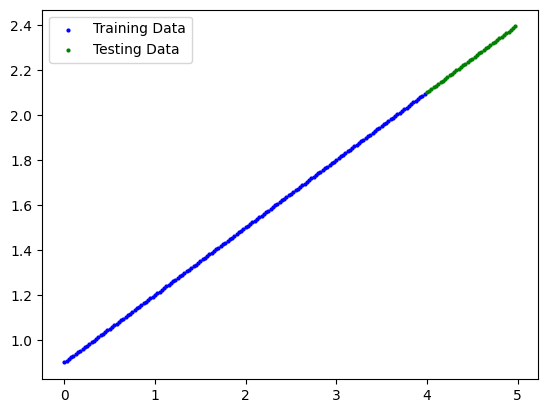

In [11]:
plot_predictions(x_train, y_train, x_test, y_test)

# Build Model

In [12]:
class LinearRegression(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
    self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

  def forward(self, x):
    return self.weight * x + self.bias

## Checking Contents of the Model

In [13]:
torch.manual_seed(25)

In [14]:
model = LinearRegression()

In [15]:
list(model.parameters())

[Parameter containing:
 tensor([1.1781], requires_grad=True),
 Parameter containing:
 tensor([0.1056], requires_grad=True)]

In [16]:
# lists named parameters
model.state_dict()

OrderedDict([('weight', tensor([1.1781])), ('bias', tensor([0.1056]))])

## Making Predictions

In [17]:
x_train = x_train.to(device)
x_test = x_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

In [18]:
# make predictions
with torch.inference_mode():
  y_pred = model(x_test)

In [19]:
print(f"number of testing samples: {len(x_test)}")
print(f"predcited values: \n{y_pred}")

number of testing samples: 40
predcited values: 
tensor([[4.8178],
        [4.8472],
        [4.8767],
        [4.9061],
        [4.9356],
        [4.9650],
        [4.9945],
        [5.0239],
        [5.0534],
        [5.0828],
        [5.1123],
        [5.1417],
        [5.1712],
        [5.2007],
        [5.2301],
        [5.2596],
        [5.2890],
        [5.3185],
        [5.3479],
        [5.3774],
        [5.4068],
        [5.4363],
        [5.4657],
        [5.4952],
        [5.5246],
        [5.5541],
        [5.5835],
        [5.6130],
        [5.6424],
        [5.6719],
        [5.7013],
        [5.7308],
        [5.7602],
        [5.7897],
        [5.8191],
        [5.8486],
        [5.8780],
        [5.9075],
        [5.9369],
        [5.9664]])


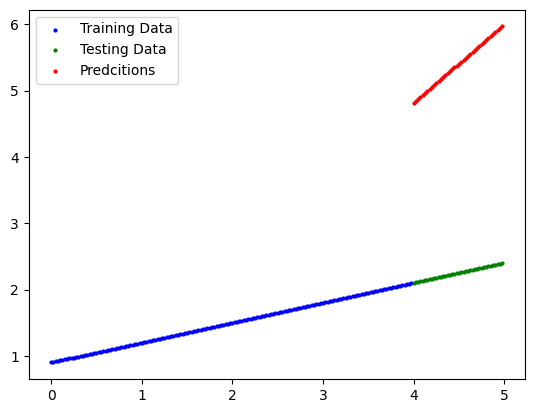

In [20]:
plot_predictions(x_train, y_train, x_test, y_test, predictions=y_pred)

In [21]:
y_test - y_pred

tensor([[-2.7178],
        [-2.7397],
        [-2.7617],
        [-2.7836],
        [-2.8056],
        [-2.8275],
        [-2.8495],
        [-2.8714],
        [-2.8934],
        [-2.9153],
        [-2.9373],
        [-2.9592],
        [-2.9812],
        [-3.0032],
        [-3.0251],
        [-3.0471],
        [-3.0690],
        [-3.0910],
        [-3.1129],
        [-3.1349],
        [-3.1568],
        [-3.1788],
        [-3.2007],
        [-3.2227],
        [-3.2446],
        [-3.2666],
        [-3.2885],
        [-3.3105],
        [-3.3324],
        [-3.3544],
        [-3.3763],
        [-3.3983],
        [-3.4202],
        [-3.4422],
        [-3.4641],
        [-3.4861],
        [-3.5080],
        [-3.5300],
        [-3.5519],
        [-3.5739]])

# Train Model

## Creating loss function and optimizer in PyTorch

For our model to learn the parameters on its own , we need to define loss function and optimizer.

In [22]:
# define loss
loss_fn = nn.L1Loss()

In [23]:
optimizer = torch.optim.SGD(
                        params=model.parameters(),
                        lr=0.01
                    )

## Creating an optimization loop

#### PyTorch Training Loop

In [24]:
# training
# 1. forward pass
# 2. loss
# 3. optimizer zero gradients
# 4. backpropagation
# 5. optimizer step

torch.manual_seed(42)
epochs = 300

epoch_count = []
train_loss_lst = []
test_loss_lst = []

for epoch in range(epochs):

  ### Training of the model

  # put the model in training mode
  model.train()

  # 1. forward pass
  output = model(x_train)

  # 2. caluclate loss
  loss = loss_fn(y_train, output)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. loss backwards
  loss.backward()

  # 5. update the parameters
  optimizer.step()

  ### Testing of the model

  model.eval()

  # 1. forward pass on the test data
  y_pred = model(x_test)

  # 2. calculate loss on test data
  with torch.inference_mode():
    test_loss = loss_fn(y_pred, y_test.type(torch.float))

    # 3. print out progress
    if epoch % 20 == 0:

      epoch_count.append(epoch)

      train_loss_lst.append(loss.detach().numpy())
      test_loss_lst.append(test_loss.detach().numpy())

      print(f"Epoch: {epoch} | Train loss: {loss:.6f} | Test Loss: {test_loss:.6f}")

Epoch: 0 | Train loss: 1.135380 | Test Loss: 3.060611
Epoch: 20 | Train loss: 0.576748 | Test Loss: 1.547545
Epoch: 40 | Train loss: 0.376971 | Test Loss: 0.720613
Epoch: 60 | Train loss: 0.338553 | Test Loss: 0.533438
Epoch: 80 | Train loss: 0.307875 | Test Loss: 0.476304
Epoch: 100 | Train loss: 0.277247 | Test Loss: 0.427437
Epoch: 120 | Train loss: 0.246618 | Test Loss: 0.380222
Epoch: 140 | Train loss: 0.215990 | Test Loss: 0.333009
Epoch: 160 | Train loss: 0.185360 | Test Loss: 0.285796
Epoch: 180 | Train loss: 0.154729 | Test Loss: 0.238583
Epoch: 200 | Train loss: 0.124100 | Test Loss: 0.189717
Epoch: 220 | Train loss: 0.093472 | Test Loss: 0.142504
Epoch: 240 | Train loss: 0.062843 | Test Loss: 0.095291
Epoch: 260 | Train loss: 0.032214 | Test Loss: 0.048078
Epoch: 280 | Train loss: 0.033193 | Test Loss: 0.009949


#### Plot Loss

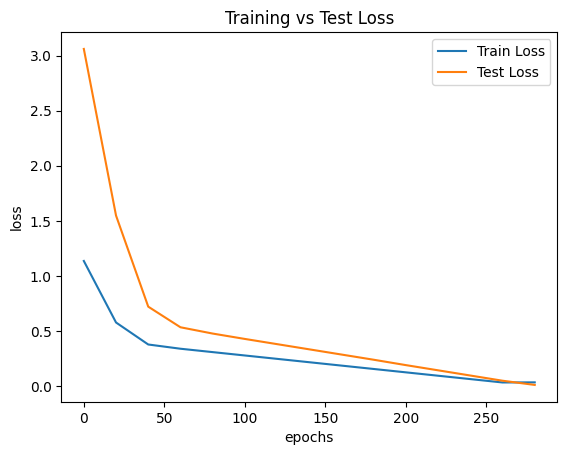

In [25]:
plt.plot(epoch_count, train_loss_lst, label = "Train Loss")
plt.plot(epoch_count, test_loss_lst, label = "Test Loss")
plt.title("Training vs Test Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [26]:
print("model leraned the following model parameters: \n", model.state_dict())

model leraned the following model parameters: 
 OrderedDict([('weight', tensor([0.3222])), ('bias', tensor([0.8996]))])


In [27]:
print(f"Actual weight: {weight} and bias: {bias}")

Actual weight: 0.3 and bias: 0.9


This is the fundamental principle of machine learning and deep learning: there are certain ideal values that characterize our data, and instead of figuring them out by hand, we may train a model to do so programmatically.

# Making Predictions with Trained PyTorch Model (Inference)

In [28]:
# set the model in evaluation mode
model.eval()

with torch.inference_mode():
  eval_preds = model(x_test)

In [29]:
eval_preds

tensor([[2.1883],
        [2.1963],
        [2.2044],
        [2.2124],
        [2.2205],
        [2.2285],
        [2.2366],
        [2.2446],
        [2.2527],
        [2.2607],
        [2.2688],
        [2.2768],
        [2.2849],
        [2.2930],
        [2.3010],
        [2.3091],
        [2.3171],
        [2.3252],
        [2.3332],
        [2.3413],
        [2.3493],
        [2.3574],
        [2.3654],
        [2.3735],
        [2.3816],
        [2.3896],
        [2.3977],
        [2.4057],
        [2.4138],
        [2.4218],
        [2.4299],
        [2.4379],
        [2.4460],
        [2.4540],
        [2.4621],
        [2.4702],
        [2.4782],
        [2.4863],
        [2.4943],
        [2.5024]])

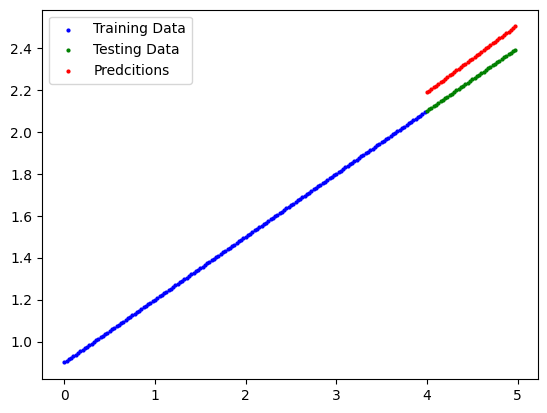

In [30]:
plot_predictions(x_train, y_train, x_test, y_test, predictions=eval_preds)

# Saving and Loading PyTorch Model

## Saving PyTorch model's `state_dict()`

In [31]:
from pathlib import Path

In [32]:
# 1. create model's directory
model_path = Path('models')
model_path.mkdir(parents=True, exist_ok=True)

# 2. create model's path
model_name = "pytorch_workflow_model.pth"
model_save_path = model_path / model_name

# 3. save model state dict
print(f"Saving model to : {model_save_path}")
torch.save(obj=model.state_dict(), f=model_save_path)

Saving model to : models/pytorch_workflow_model.pth


In [33]:
# checking saved file path
!ls -l models/pytorch_workflow_model.pth

-rw-r--r-- 1 root root 1650 Sep 21 04:16 models/pytorch_workflow_model.pth


## Loading Saved PyTorch model's `state_dict()`

In [34]:
loaded_model = LinearRegression()
loaded_model.load_state_dict(torch.load(f=model_save_path))

<ipython-input-34-d71b651eebe8>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(f=model_save_path))


<All keys matched successfully>

Now, let's make some predictions

In [35]:
loaded_model.eval()

with torch.inference_mode():
  preds = loaded_model(x_test)

In [36]:
# let's compare previous model's predictions with this loaded model
eval_preds == preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

It looks like both the predictions are the same before saving the model and after loading the saved model. This suggests that our model is performing as expected.